In [ ]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [ ]:
# Dataset
df = pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# fitur dan target
X = df[['Glucose', 'BMI', 'Age', 'BloodPressure']]
y = df['Outcome']

In [ ]:
# normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# model KNN
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# prediksi
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7402597402597403


In [ ]:
# pengujian variasi K pada KNN
for k in [3,5,7]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"K={k}, Accuracy={accuracy_score(y_test, y_pred)}")

K=3, Accuracy=0.7402597402597403
K=5, Accuracy=0.7207792207792207
K=7, Accuracy=0.7597402597402597


In [ ]:
# buat grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

In [ ]:
# ambil rata-rata tiap kolom
mean_vals = df.mean(numeric_only=True)

# buat grid dari 2 fitur utama (misalnya ambil 2 pertama)
grid = np.c_[xx.ravel(), yy.ravel()]

# tambahkan fitur sisanya (HARUS sesuai urutan X)
grid_full = np.c_[
    grid,
    np.full(xx.ravel().shape, mean_vals['Age']),
    np.full(xx.ravel().shape, mean_vals['BloodPressure'])
]

# prediksi
Z = model.predict(grid_full)
Z = Z.reshape(xx.shape)

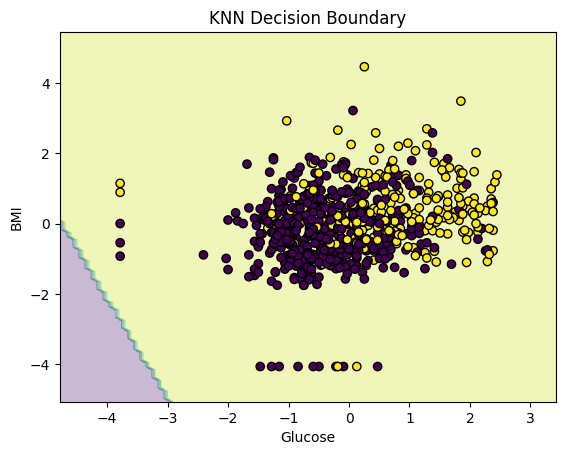

In [ ]:
# plot grafik
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolor='k')

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("KNN Decision Boundary")
plt.show()

Hasil analisis menunjukkan bahwa fitur yang digunakan, yaitu Glucose, BMI, Age, dan BloodPressure, memiliki pengaruh terhadap kemungkinan seseorang mengalami diabetes. Secara umum, nilai Glucose dan BMI yang lebih tinggi cenderung meningkatkan peluang seseorang terklasifikasi sebagai diabetes, sementara Age dan BloodPressure juga turut memberikan kontribusi dalam proses klasifikasi.

Model K-Nearest Neighbors (KNN) mampu mengklasifikasikan data testing dengan cukup baik, yang terlihat dari nilai akurasi pada setiap variasi nilai K. Berdasarkan hasil pengujian, nilai K = 7 memberikan akurasi terbaik sebesar 0,759 dibandingkan K = 3 sebesar 0,740 dan K = 5 sebesar 0,720, sehingga dapat dikatakan bahwa K = 7 merupakan nilai yang paling optimal pada percobaan ini.

Namun, hasil ini masih memiliki keterbatasan karena fitur yang digunakan belum mencakup seluruh variabel dalam dataset. Penggunaan lebih banyak fitur berpotensi meningkatkan performa model.

## Skenario Pengujian KNN

- Pengujian ini dilakukan untuk melihat seberapa baik algoritma KNN dalam mengklasifikasikan data diabetes, sekaligus mengetahui pengaruh nilai K terhadap akurasi.

- Dataset yang digunakan adalah Pima Indians Diabetes dari Kaggle, dengan fitur Pregnancies,	Glucose,	BloodPressure,	SkinThickness,	Insulin,	BMI,	DiabetesPedigreeFunction,	Age, serta target Outcome (0 = tidak diabetes, 1 = diabetes).

- Data dibagi menjadi 80% untuk training dan 20% untuk testing.

- Sebelum digunakan, data dinormalisasi menggunakan StandardScaler agar skalanya sama.
- Pengujian dilakukan dengan beberapa nilai K yaitu 3, 5, dan 7 untuk dibandingkan hasil akurasinya, dengan metrik evaluasi yang digunakan adalah accuracy.

